In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

In [22]:
# --- Step 1: Load Excel data ---
file_path = "badge_positions_tracked_01.xlsx"
df = pd.read_excel(file_path)

In [23]:
# --- Step 2: Extract time and hand_1_x ---
# time = df["second"].values[3750:4250]
# signal = df["hand_2_x"].values[3750:4250]
time = df["second"].values[:250]
signal = df["hand_2_x"].values[:250]

In [24]:
def plot_signal(x, y, xlabel="Time (s)", ylabel="Signal", title="Signal vs Time", trend_line = None):
    
    plt.figure(figsize=(10, 5))
    plt.plot(x, y, linewidth=1.5)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if trend_line is not None:
        plt.plot(x, trend_line, color='red', linestyle='--', label='Trend Line')
        plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

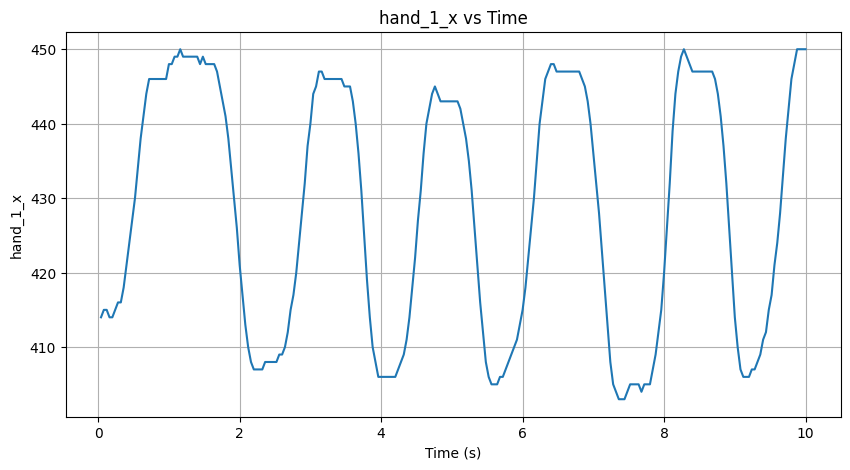

In [25]:
plot_signal(time, signal, ylabel="hand_1_x", title="hand_1_x vs Time")

In [26]:
T = 1/25
X = np.fft.fft(signal)
N = len(X)
freqs = np.fft.fftfreq(N, T)

In [27]:
positive_freqs = freqs[:N//2]
magnitude = np.abs(X[:N//2]) / N

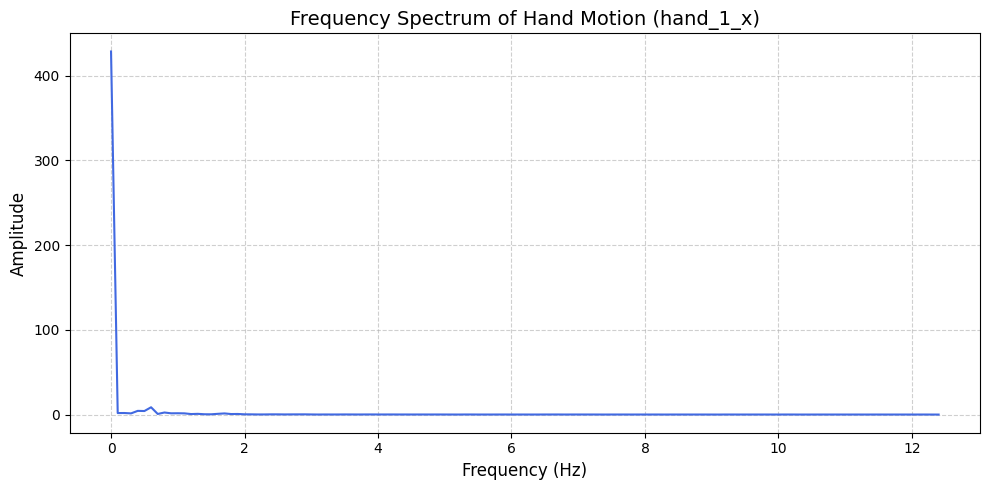

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(positive_freqs, magnitude, color='royalblue', lw=1.5)
plt.title("Frequency Spectrum of Hand Motion (hand_1_x)", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [29]:
for i in range(len(positive_freqs)):
    print(f"Index: {i}, Frequency: {positive_freqs[i]:.2f} Hz, Amplitude: {magnitude[i]:.4f}")

Index: 0, Frequency: 0.00 Hz, Amplitude: 428.4960
Index: 1, Frequency: 0.10 Hz, Amplitude: 1.8117
Index: 2, Frequency: 0.20 Hz, Amplitude: 1.8737
Index: 3, Frequency: 0.30 Hz, Amplitude: 1.4282
Index: 4, Frequency: 0.40 Hz, Amplitude: 4.3883
Index: 5, Frequency: 0.50 Hz, Amplitude: 4.2163
Index: 6, Frequency: 0.60 Hz, Amplitude: 8.6455
Index: 7, Frequency: 0.70 Hz, Amplitude: 0.7502
Index: 8, Frequency: 0.80 Hz, Amplitude: 2.4550
Index: 9, Frequency: 0.90 Hz, Amplitude: 1.5215
Index: 10, Frequency: 1.00 Hz, Amplitude: 1.5896
Index: 11, Frequency: 1.10 Hz, Amplitude: 1.4585
Index: 12, Frequency: 1.20 Hz, Amplitude: 0.6317
Index: 13, Frequency: 1.30 Hz, Amplitude: 0.8882
Index: 14, Frequency: 1.40 Hz, Amplitude: 0.4069
Index: 15, Frequency: 1.50 Hz, Amplitude: 0.3526
Index: 16, Frequency: 1.60 Hz, Amplitude: 0.9084
Index: 17, Frequency: 1.70 Hz, Amplitude: 1.3783
Index: 18, Frequency: 1.80 Hz, Amplitude: 0.6479
Index: 19, Frequency: 1.90 Hz, Amplitude: 0.7362
Index: 20, Frequency: 2.00 H

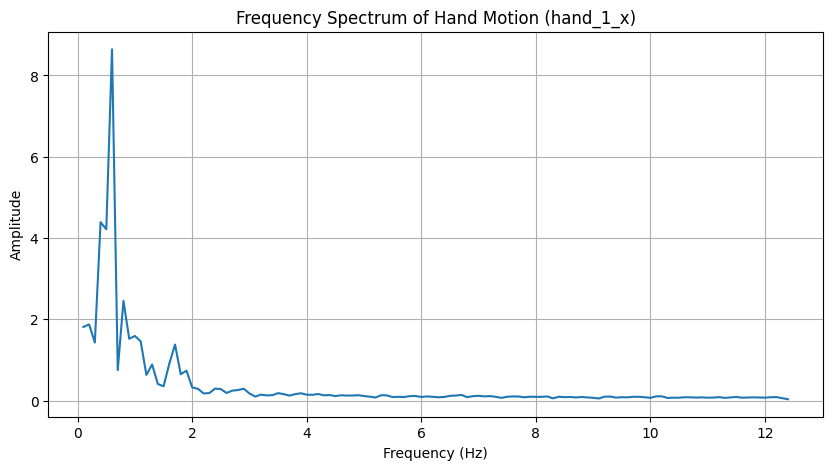

In [30]:
plot_signal(positive_freqs[1:], magnitude[1:], xlabel="Frequency (Hz)", ylabel="Amplitude", title="Frequency Spectrum of Hand Motion (hand_1_x)")